In [11]:
from sklearn.model_selection import validation_curve
from sklearn.metrics import classification_report, accuracy_score, roc_curve, roc_auc_score, confusion_matrix

import pandas as pd
import numpy as np

import time
import pickle

import warnings
warnings.filterwarnings('ignore')

In [12]:
X_test = np.array(pd.read_csv('X_test_preprocessed.csv'))
X_train = np.array(pd.read_csv('X_train_resampled.csv'))

y_test = np.array(pd.read_excel('y_test.xlsx'))
y_train = np.array(pd.read_excel('y_train.xlsx'))

# 1. Lựa chọn thuật toán và huấn luyện

In [13]:
# Install xgboost if it's not available in the environment
%pip install xgboost

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

Note: you may need to restart the kernel to use updated packages.


## 1.1. Random Forest

In [14]:
rfc = RandomForestClassifier(n_estimators = 200, min_samples_leaf = 5, min_samples_split = 20, random_state = 2025)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)
print(f"Accuracy of Random Forest Classifier: {accuracy_score(y_test, y_pred)}")

Accuracy of Random Forest Classifier: 0.8558421851289834


In [15]:
with open("RandomForest.pkl", "wb") as f:
    pickle.dump(rfc, f)

## 1.2. SVM

In [16]:
# C (hệ số phạt), gamma, tol (cao -> chậm): ngưỡng hội tụ
svm = SVC(kernel='rbf', probability = True, tol = 0.0009, cache_size = 500, random_state = 2025)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print(f"Accuracy of SVM: {accuracy_score(y_test, y_pred_svm)}")

Accuracy of SVM: 0.8270106221547799


In [17]:
with open("SVM.pkl", "wb") as f:
    pickle.dump(svm, f)

## 1.3. XGBClassifier

In [18]:
# Tăng estimators -> giảm learning rate (số nhỏ -> học chậm), 
xgb = XGBClassifier(n_estimators = 200, learning_rate = 0.05, max_depth = 5, min_child_weight = 3, colsample_bytree=0.6, 
                    gamma = 0.1, reg_alpha=0.1, objective='binary:logistic', tree_method = 'hist', random_state = 2025)
xgb.fit(X_train, y_train)

y_pred_xg = xgb.predict(X_test)

print(f"Accuracy of XGBClassifier: {accuracy_score(y_test, y_pred_xg)}")

Accuracy of XGBClassifier: 0.8543247344461306


In [19]:
with open("XGBoost.pkl", "wb") as f:
    pickle.dump(xgb, f)

**1. Cấu trúc cây:**
max_depth: [3, 5, 7], 
min_child_weight: [1, 3, 5], 
gamma: [0, 0.1, 0.3]
**2. sampling**
subsample: [0.7, 0.8, 0.9], 
colsample_bytree: [0.4, 0.6, 0.8]
**3. regularization**
reg_alpha: [0, 0.1, 0.5], 
reg_lambda: [0.5, 1, 2]

# 2. Điều chỉnh tham số

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

**Mục đích:** không phải là tìm tham số tốt nhất, mà là kiểm soát BIAS–VARIANCE

**Thứ tự:** “năng lực mô hình” → “ổn định” (sampling) → “regularization” → "optimization"

In [21]:
percent = len([y for y in y_train if (y == 1)])/len(y_train)
percent

0.5

***--> Đây là bài toán binary (balanced)***

In [22]:
def hyperparameter_tuning(param_dist_list: list, n_iter: int, model):
    for param_dist in param_dist_list:
        random_search = RandomizedSearchCV(
            model,
            param_dist,
            n_iter = n_iter,
            scoring = 'roc_auc',
            cv = 5,
            n_jobs = -1
        )
        random_search.fit(X_train, y_train)
        model = random_search.best_estimator_

    return model, random_search.best_score_

## 2.1. RandomForest

In [23]:
param_dist_list = [
    {
        'max_depth': [5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5]
    },
    {
        'max_features': ['sqrt', 'log2', 0.3, 0.5],
        'bootstrap': [True, False]
    },
    {
        'n_estimators': [200, 400, 600]
    },
]

In [24]:
tuned_rf, score_best_model = hyperparameter_tuning(param_dist_list, 15, rfc)

In [25]:
with open("tuned_rf.pkl", "wb") as f:
        pickle.dump(tuned_rf, f)

In [26]:
y_pred_tuned_rf = tuned_rf.predict(X_test)
print(f"Accuracy of Random Forest Classifier: {accuracy_score(y_test, y_pred_tuned_rf)}")

Accuracy of Random Forest Classifier: 0.8573596358118362


## 2.2. SVM

In [27]:
param_dist_list_svm = [
    {
        'C': [1e-3, 1e-1, 1, 10],
        'kernel': ['linear', 'rbf']
    },
    {
        'tol': [1e-3, 1e-2, 1e-1], # Optimization
        'max_iter': [5000, 8000]
    }
]

In [28]:
tuned_svm, score_best_svm = hyperparameter_tuning(param_dist_list_svm, 10, svm)

In [29]:
with open("tuned_svm.pkl", "wb") as f:
        pickle.dump(tuned_svm, f)

In [30]:
y_pred_tuned_svm = tuned_svm.predict(X_test)
print(f"Accuracy of Random Forest Classifier: {accuracy_score(y_test, y_pred_tuned_svm)}")

Accuracy of Random Forest Classifier: 0.8292867981790591


## 2.3. XGBClassifier

In [31]:
param_dist_list_xgb = [
    {
        'max_depth': [3, 5, 7], 
        'min_child_weight': [1, 3, 5]
    },
    {
        'subsample': [0.7, 0.8, 0.9], 
        'colsample_bytree': [0.4, 0.6, 0.8]
    },
    {
        'gamma': [0, 0.1, 0.3], # phạt như thế nào
        'reg_alpha': [0, 0.1, 0.5]
    },
    {
        'learning_rate': [0.02, 0.05, 0.08],
        'n_estimators': [100, 200, 400]
    }
]

In [32]:
tuned_xgb, score_best_xgb = hyperparameter_tuning(param_dist_list_xgb, 9, xgb)

In [33]:
with open("tuned_xgb.pkl", "wb") as f:
        pickle.dump(tuned_xgb, f)

In [34]:
y_pred_tuned_xgb = tuned_xgb.predict(X_test)
print(f"Accuracy of Random Forest Classifier: {accuracy_score(y_test, y_pred_tuned_xgb)}")

Accuracy of Random Forest Classifier: 0.8641881638846738


In [35]:
models = {'RandomForest': rfc, 'tuned_rf': tuned_rf, 'SVM': svm, 'tuned_svm': tuned_svm, 'XGBoost': xgb, 'tuned_xgb': tuned_xgb}

In [36]:
df = pd.DataFrame(columns = models.keys(), index = ['gap_train_val', 'val_std', 'score_changing_seed', 'score_dropping_feats', 'train_time', 'infer_time', 'memory'])

# 3. So sánh hiệu suất

**So sánh tổng chi phí và lợi ích**

## 3.1. Generalization

**Model có giữ được chất lượng khi gặp data mới không**

In [37]:
from sklearn.model_selection import cross_validate

In [38]:
def estimate_generalization(model):
    cv_result = cross_validate(
        model,
        X_train, y_train,
        cv = 5,
        return_train_score = True
    )

    train_scores = cv_result['train_score']
    val_scores = cv_result['test_score']

    gap = train_scores.mean() - val_scores.mean()
    val_std = np.std(val_scores)

    return gap, val_std

In [39]:
gen_lst = []
for name, model in models.items():
    gap, val_std = estimate_generalization(model)
    gen_lst.append({f'{name}': [float(gap), float(val_std)]})

## 3.2. Robustness

**Nếu data hơi thay đổi (thêm bớt feature), model có ổn định không?**

In [40]:
def score_by_changing_seeds(model):
    scores = []
    for seed in [0, 1, 2, 3, 4]:
        model.set_params(random_state = seed)
        model.fit(X_train, y_train)
        scores.append(model.score(X_test, y_test))
    
    return np.std(scores)

In [41]:
def drop_features(X, drop_ratio = 0.1):
    X_new = X.copy()
    n_drop = int(X.shape[1] * drop_ratio)
    drop_idx = np.random.choice(X.shape[1], n_drop, replace = False)
    X_new[:, drop_idx] = 0
    return X_new

def score_by_dropping_feats(model):
    scores = []
    for _ in range(10):
        X_mod = drop_features(X_test, 0.1)
        scores.append(model.score(X_mod, y_test))

    return np.std(scores)

In [42]:
rob_lst = []
for name, model in models.items():
    score_seeds = score_by_changing_seeds(model)
    score_drop_feats = score_by_dropping_feats(model)
    rob_lst.append({f'{name}': [float(score_seeds), float(score_drop_feats)]})

## 3.3. Cost & Time

In [43]:
import os

In [44]:
def estimate_train_time(model):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    end_time = time.perf_counter()
    train_time = end_time - start
    
    return train_time

In [45]:
def estimate_inference_time(model):
    start = time.perf_counter()
    model.predict(X_test)
    end_time = time.perf_counter()
    infer_time = end_time - start
    
    return infer_time

In [46]:
def estimate_memory(model, name_model):
    mem = os.path.getsize(f"{name_model}.pkl") / 1024  # KB

    return mem

In [47]:
ct_lst = []
for name, model in models.items():
    train_time = estimate_train_time(model)
    infer_time = estimate_inference_time(model)
    mem = estimate_memory(model, name)
    ct_lst.append({f'{name}': [float(train_time), float(infer_time), float(mem)]})

## 3.4. Thống kê

In [48]:
from collections import defaultdict

In [49]:
lst = []
lst = gen_lst + rob_lst + ct_lst

In [50]:
result = defaultdict(list)

for d in lst:
    for key, value in d.items():
        value = [val for val in value]
        result[key].extend(value)

In [51]:
res = dict(result)

In [52]:
for col in df.columns:
    df[col] = res[col]

In [53]:
df['SVM'] = round(df['SVM'], 2)
df['tuned_svm'] = round(df['tuned_svm'], 2)

In [54]:
df

,RandomForest,tuned_rf,SVM,tuned_svm,XGBoost,tuned_xgb
gap_train_val,0.042994,0.089103,0.02,0.04,0.034417,0.088407
val_std,0.027778,0.038560,0.02,0.03,0.037730,0.043033
score_changing_seed,0.002697,0.002331,0.00,0.00,0.001919,0.003373
score_dropping_feats,0.006205,0.013673,0.01,0.03,0.018549,0.010922
train_time,3.074207,14.992262,11.53,12.59,0.395251,1.253240
infer_time,0.101605,0.276415,0.57,0.56,0.003550,0.006935
memory,8064.778320,97972.805664,721.45,626.03,360.034180,1437.030273


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
new_order = ['RandomForest', 'SVM', 'XGBoost', 'tuned_rf', 'tuned_svm','tuned_xgb']
df = df[new_order]

In [57]:
df

,RandomForest,SVM,XGBoost,tuned_rf,tuned_svm,tuned_xgb
gap_train_val,0.042994,0.02,0.034417,0.089103,0.04,0.088407
val_std,0.027778,0.02,0.037730,0.038560,0.03,0.043033
score_changing_seed,0.002697,0.00,0.001919,0.002331,0.00,0.003373
score_dropping_feats,0.006205,0.01,0.018549,0.013673,0.03,0.010922
train_time,3.074207,11.53,0.395251,14.992262,12.59,1.253240
infer_time,0.101605,0.57,0.003550,0.276415,0.56,0.006935
memory,8064.778320,721.45,360.034180,97972.805664,626.03,1437.030273


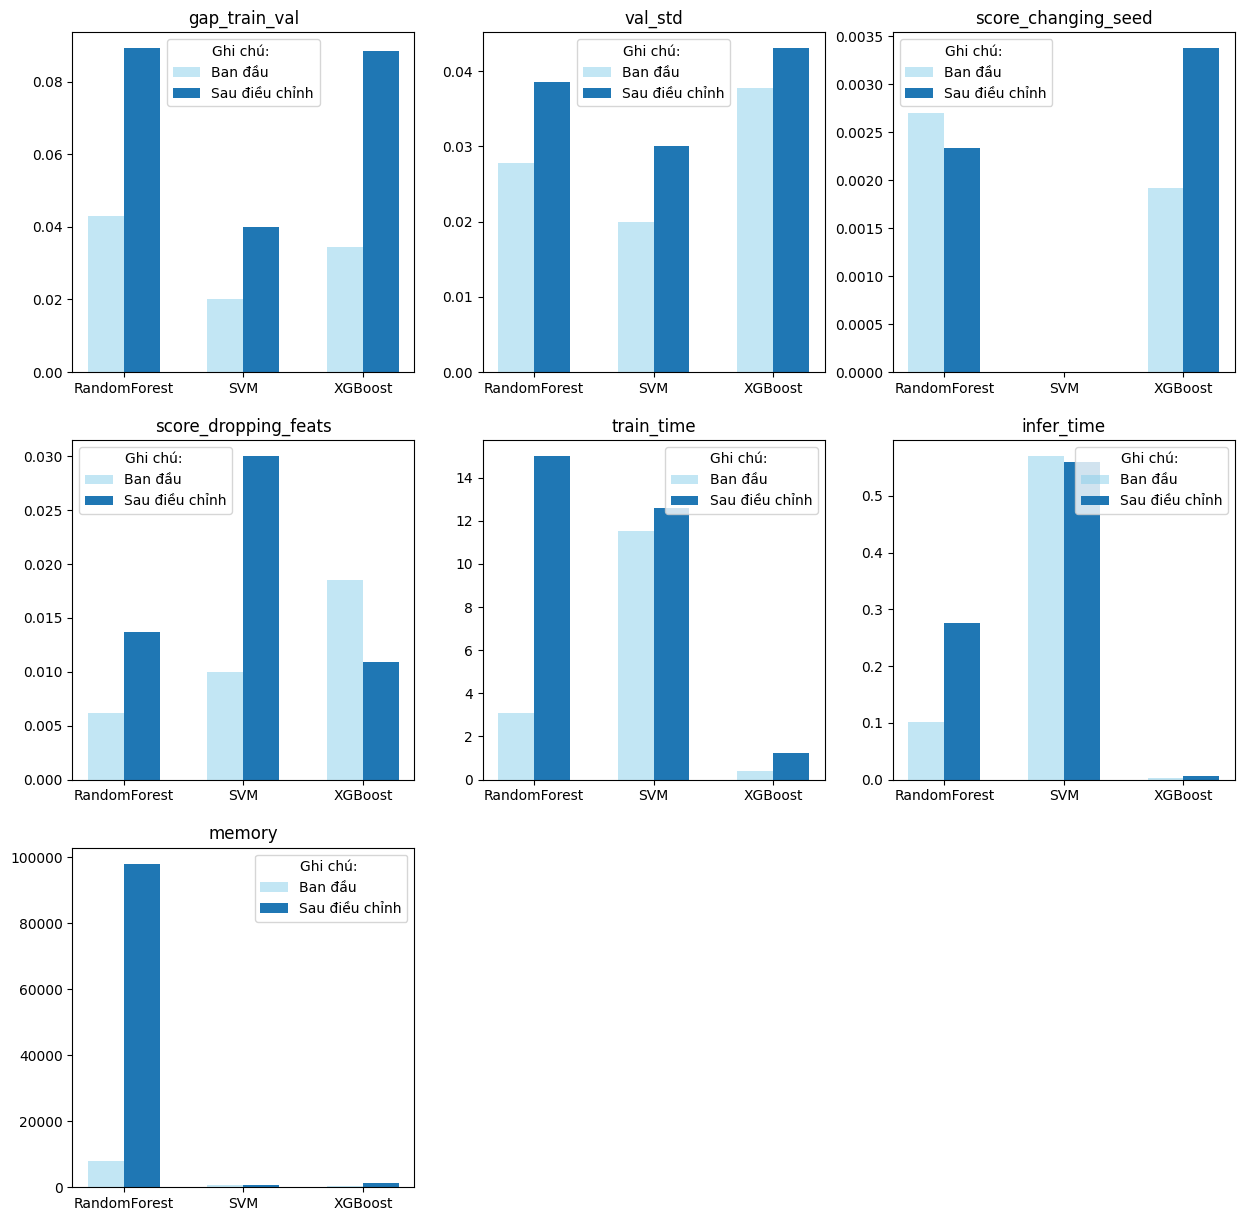

In [58]:
plt.figure(figsize=(15, 15))
x_ = ['RandomForest', 'SVM', 'XGBoost']
tuned_x_ = ['tuned_rf', 'tuned_svm', 'tuned_xgb']
idx = np.arange(3)
width = 0.30

for i, col in enumerate(df.index):
    plt.subplot(3, 3, i + 1)

    plt.bar(idx, df.loc[col, x_], width, color = 'skyblue', label = 'Ban đầu', alpha = 0.5)
    plt.bar(idx + width, df.loc[col, tuned_x_], width, label = 'Sau điều chỉnh')
    plt.xticks(idx + width/2, x_)
    plt.title(f'{col}')
    plt.legend(title = 'Ghi chú: ')

plt.show()

# 4. Đánh giá mô hình

## 4.1. Đánh giá mô hình trên tập test với các chỉ số đánh giá: accuracy, precision, recall , f1

In [59]:
rf_report = classification_report(y_test, y_pred, output_dict = True)
df1 = pd.DataFrame(rf_report).transpose()
df1

,precision,recall,f1-score,support
0,0.901064,0.897246,0.899151,944.000000
1,0.743386,0.751337,0.747340,374.000000
accuracy,0.855842,0.855842,0.855842,0.855842
macro avg,0.822225,0.824291,0.823246,1318.000000
weighted avg,0.856321,0.855842,0.856073,1318.000000


In [60]:
svm_report = classification_report(y_test, y_pred_svm, output_dict = True)
df2 = pd.DataFrame(svm_report).transpose()
df2

,precision,recall,f1-score,support
0,0.920188,0.830508,0.873051,944.000000
1,0.656652,0.818182,0.728571,374.000000
accuracy,0.827011,0.827011,0.827011,0.827011
macro avg,0.788420,0.824345,0.800811,1318.000000
weighted avg,0.845406,0.827011,0.832053,1318.000000


In [61]:
xgb_report = classification_report(y_test, y_pred_xg, output_dict = True)
df3 = pd.DataFrame(xgb_report).transpose()
df3

,precision,recall,f1-score,support
0,0.900000,0.896186,0.898089,944.000000
1,0.740741,0.748663,0.744681,374.000000
accuracy,0.854325,0.854325,0.854325,0.854325
macro avg,0.820370,0.822425,0.821385,1318.000000
weighted avg,0.854808,0.854325,0.854558,1318.000000


In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [63]:
preds = [y_pred, y_pred_svm, y_pred_xg]

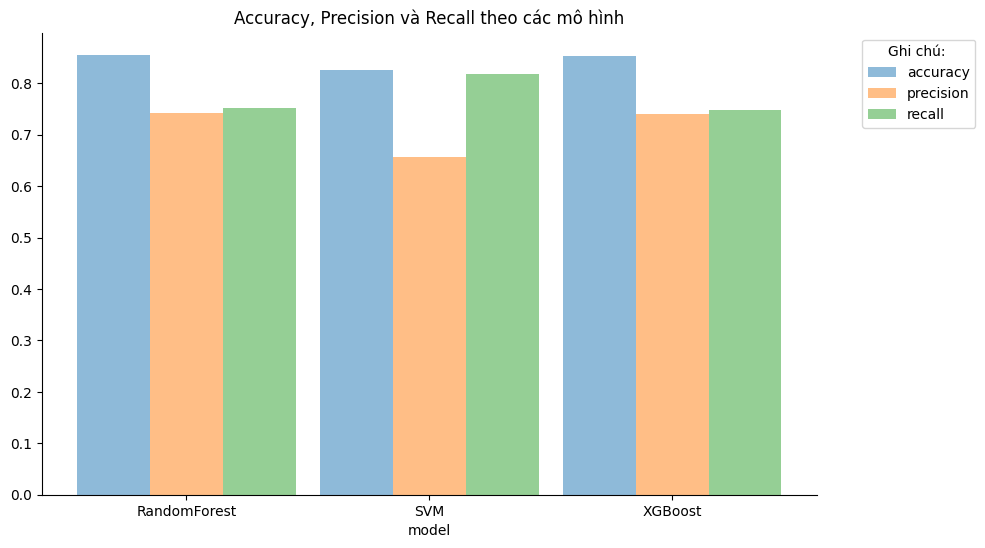

In [64]:
plt.figure(figsize=(10, 6))

x_ = ['RandomForest', 'SVM', 'XGBoost']
idx = np.arange(3)
width = 0.30

plt.bar(idx, [accuracy_score(y_test, x1) for x1 in preds], width, label = 'accuracy', alpha = 0.5)
plt.bar(idx + width, [precision_score(y_test, x2) for x2 in preds], width, label = 'precision', alpha = 0.5)
plt.bar(idx + width*2, [recall_score(y_test, x3) for x3 in preds], width, label = 'recall', alpha = 0.5)

plt.xticks(idx + width, x_)
plt.title('Accuracy, Precision và Recall theo các mô hình')
plt.legend(title = 'Ghi chú: ', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.xlabel('model')
sns.despine()
plt.show()

## 4.2. Confusion Matrix

In [65]:
rf_cm = confusion_matrix(y_test, y_pred)

In [66]:
svm_cm = confusion_matrix(y_test, y_pred_svm)

In [67]:
xgb_cm = confusion_matrix(y_test, y_pred_xg)

In [68]:
cm = {'RandomForest': rf_cm, 'SVM': svm_cm, 'XGBoost': xgb_cm}

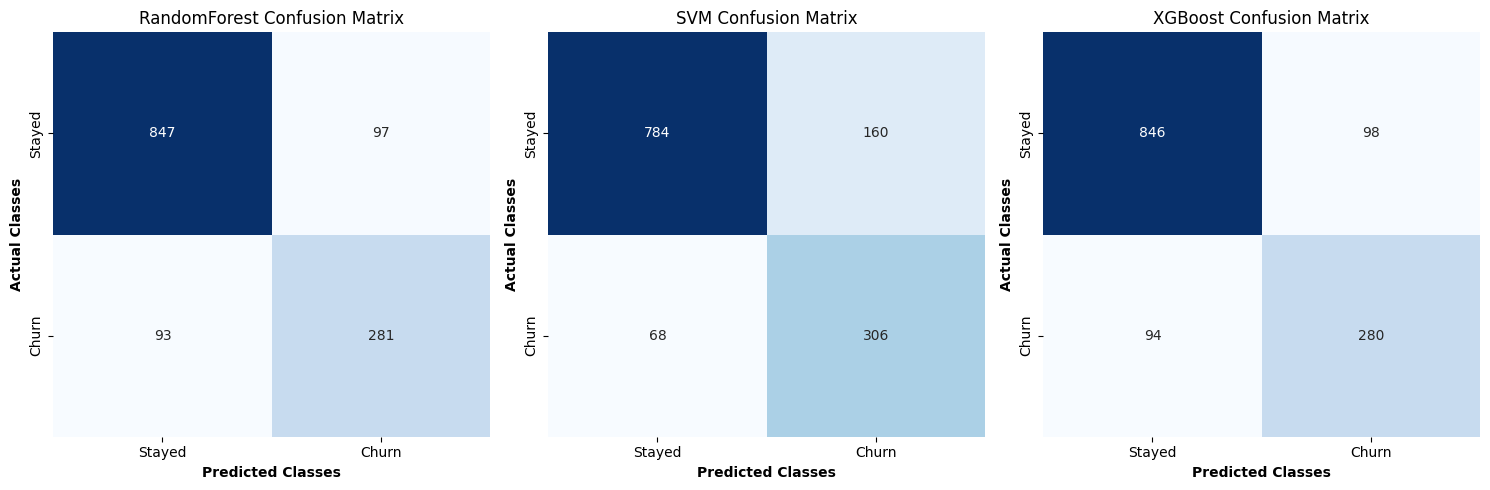

In [69]:
plt.figure(figsize = (15, 5))
for i, name in enumerate(['RandomForest', 'SVM', 'XGBoost']):
    plt.subplot(1, 3, i + 1)

    sns.heatmap(cm[name], cmap = 'Blues', cbar = False, annot = True, fmt = 'd')
    plt.xticks(np.arange(2) + 0.5, ['Stayed', 'Churn'])
    plt.yticks(np.arange(2) + 0.5, ['Stayed', 'Churn'])
    plt.xlabel("Predicted Classes", fontweight = 'bold')
    plt.ylabel("Actual Classes", fontweight = 'bold')
    plt.title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

## 4.3. Đường cong ROC - AUC

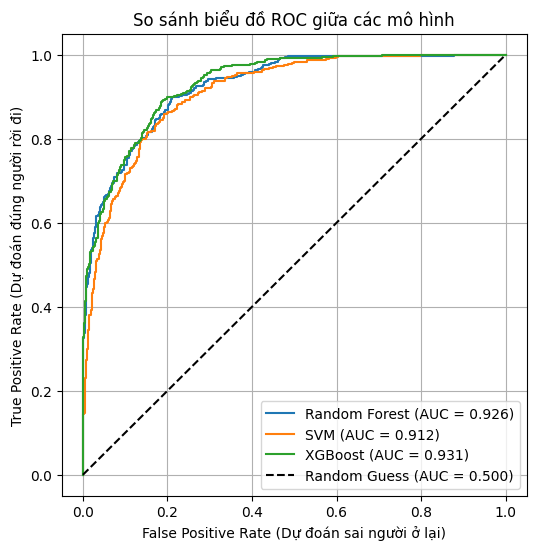

In [70]:
rf_probs = rfc.predict_proba(X_test)[:, 1]
svm_probs = svm.predict_proba(X_test)[:, 1]
xgb_probs = xgb.predict_proba(X_test)[:, 1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

rf_auc = roc_auc_score(y_test, rf_probs)
svm_auc = roc_auc_score(y_test, svm_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

plt.figure(figsize = (6, 6))
plt.plot(rf_fpr, rf_tpr, label = f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(svm_fpr, svm_tpr, label = f'SVM (AUC = {svm_auc:.3f})')
plt.plot(xgb_fpr, xgb_tpr, label = f'XGBoost (AUC = {xgb_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label = 'Random Guess (AUC = 0.500)')

plt.xlabel('False Positive Rate (Dự đoán sai người ở lại)')
plt.ylabel('True Positive Rate (Dự đoán đúng người rời đi)')
plt.title('So sánh biểu đồ ROC giữa các mô hình')
plt.legend()
plt.grid(True)
plt.show()

## 4.4. Kiểm tra Overfitting/Underfitting

In [71]:
from sklearn.model_selection import LearningCurveDisplay

In [72]:
rfc_lc = RandomForestClassifier(min_samples_leaf=5, min_samples_split=20, n_estimators=200, random_state=2025)

In [73]:
svm_lc = SVC(cache_size=500, probability=True, random_state=2025, tol=0.0009)

In [74]:
xgb_lc = XGBClassifier(n_estimators = 200, learning_rate = 0.05, max_depth = 5, min_child_weight = 3, colsample_bytree=0.6, 
                        gamma = 0.1, reg_alpha=0.1, objective='binary:logistic', tree_method = 'hist', random_state = 2025)

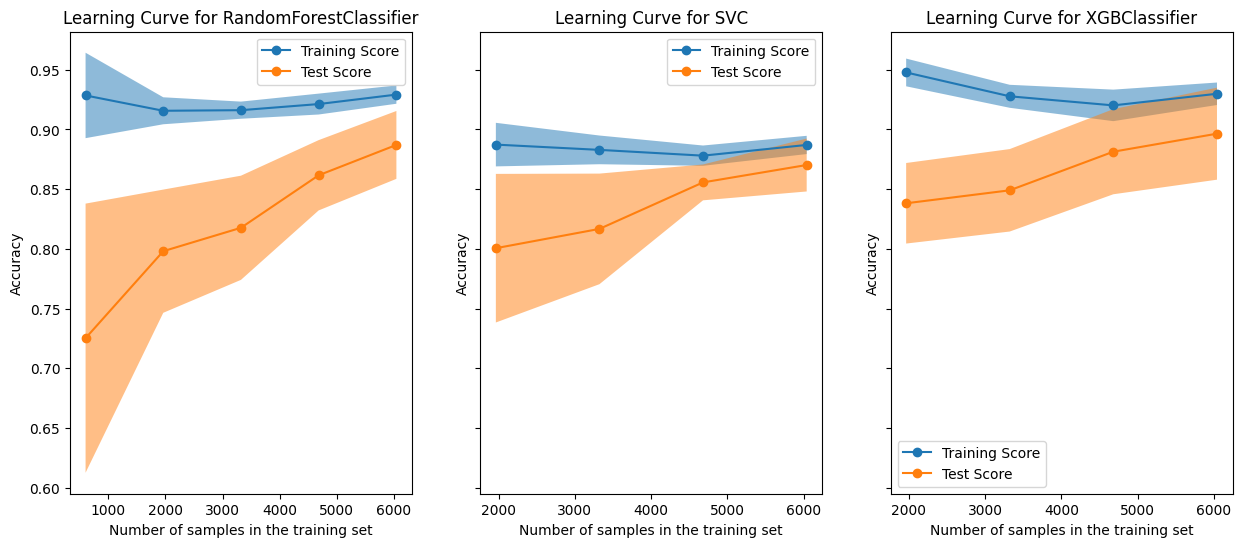

In [75]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharey=True)

common_params = {
    "X": X_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": 5,
    "score_type": "both",
    "n_jobs": 4,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "Accuracy",
}

for idx, model in enumerate([rfc_lc, svm_lc, xgb_lc]):
    LearningCurveDisplay.from_estimator(model, **common_params, ax = ax[idx])
    handles, label = ax[idx].get_legend_handles_labels()
    ax[idx].legend(handles[:2], ["Training Score", "Test Score"])
    ax[idx].set_title(f"Learning Curve for {model.__class__.__name__}")

## 4.5. Giải thích mô hình (Feature Importance -> svm không có, SHAP, Coefficients -> chỉ dành do linear)

### 4.5.1. Feature Importance

In [76]:
X1 = pd.read_csv("X_train_resampled.csv")

In [77]:
xgb_if = pd.DataFrame(xgb.feature_importances_, index = X1.columns, columns = ['importance'])
xgb_if.sort_values(by = 'importance', ascending = False, inplace = True)

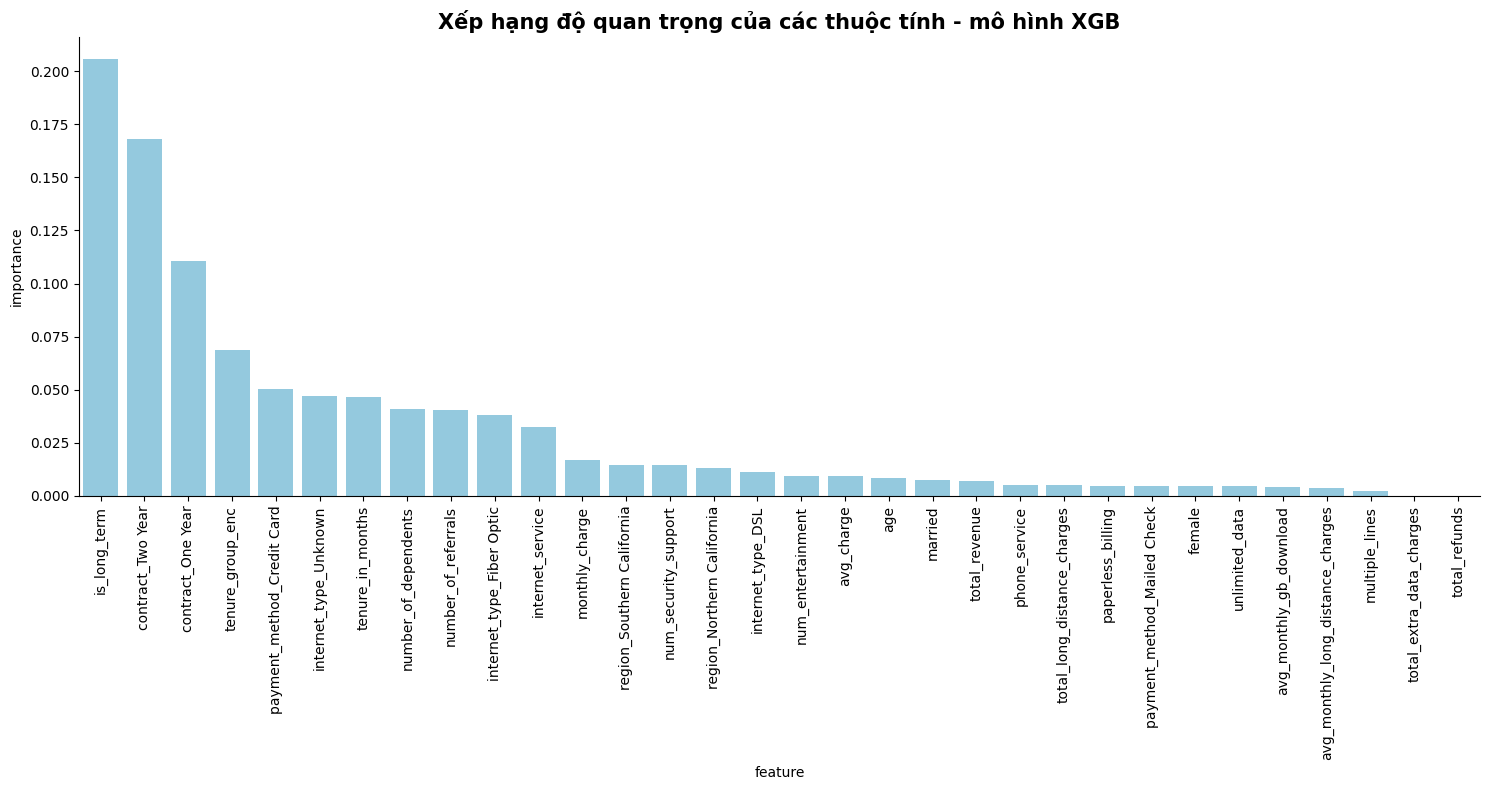

In [78]:
plt.figure(figsize = (15, 8))
sns.barplot(data = xgb_if, x = xgb_if.index, y = 'importance', color = 'skyblue')

plt.xlabel('feature')
plt.xticks(rotation=90)

plt.title("Xếp hạng độ quan trọng của các thuộc tính - mô hình XGB", fontsize = 15, fontweight = 'bold')
sns.despine()
plt.tight_layout()
plt.show()

### 4.5.3. SHAP

In [79]:
import shap
shap.initjs()

ModuleNotFoundError: No module named 'shap'

In [ ]:
X2 = pd.read_csv('X_test_preprocessed.csv')

**XGBoost**

In [ ]:
xgb_explainer = shap.Explainer(
    xgb,
    shap.sample(X1, 7000)
)

xgb_shaps = xgb_explainer(X2)

In [ ]:
np.shape(xgb_shaps)

(1318, 32)

**Mức độ ảnh hưởng của từng thuộc tính đến kết quả phân lớp là 1**

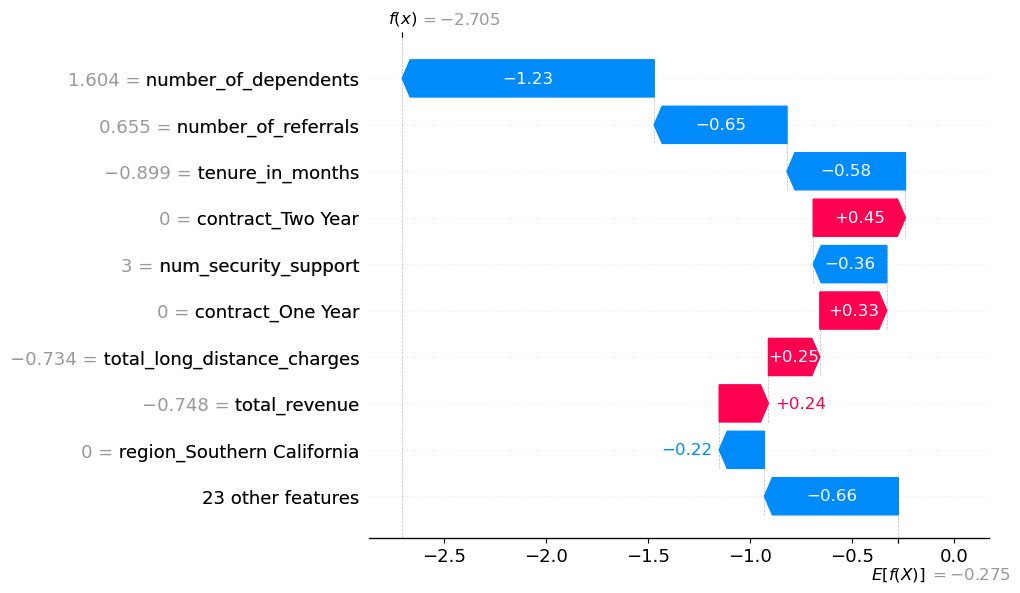

In [ ]:
shap.plots.waterfall(xgb_shaps[0])

**=> Đây là hình vẽ tác động của từng feature lên kết quả dự đoán riêng của dòng thứ nhất, trong đó f(x) là log của kết quả dự đoán. Ví dụ: Khi number_of_dependents = 1.604 thì E[f(x)] giảm 1.23**

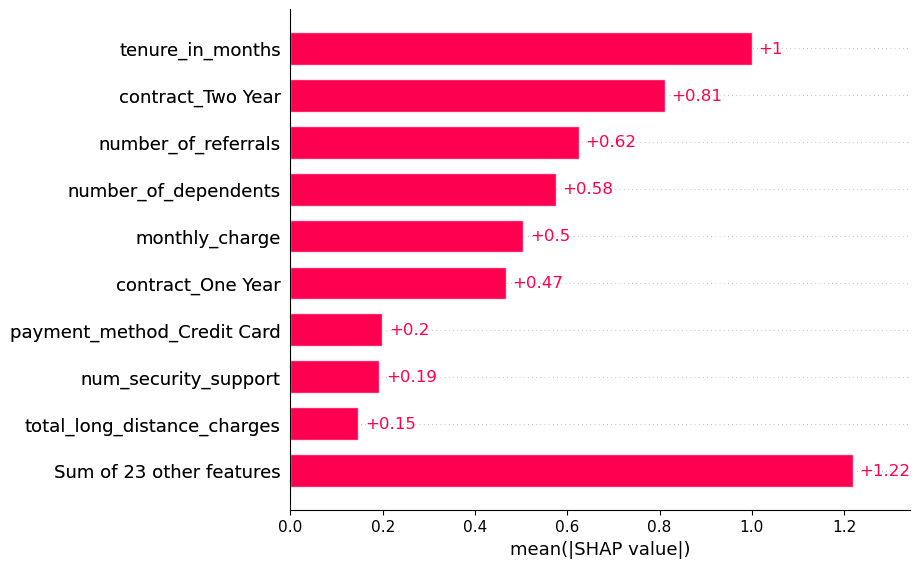

In [ ]:
shap.plots.bar(xgb_shaps)

**=> Trung bình trị(tác động) của từng thuộc tính**

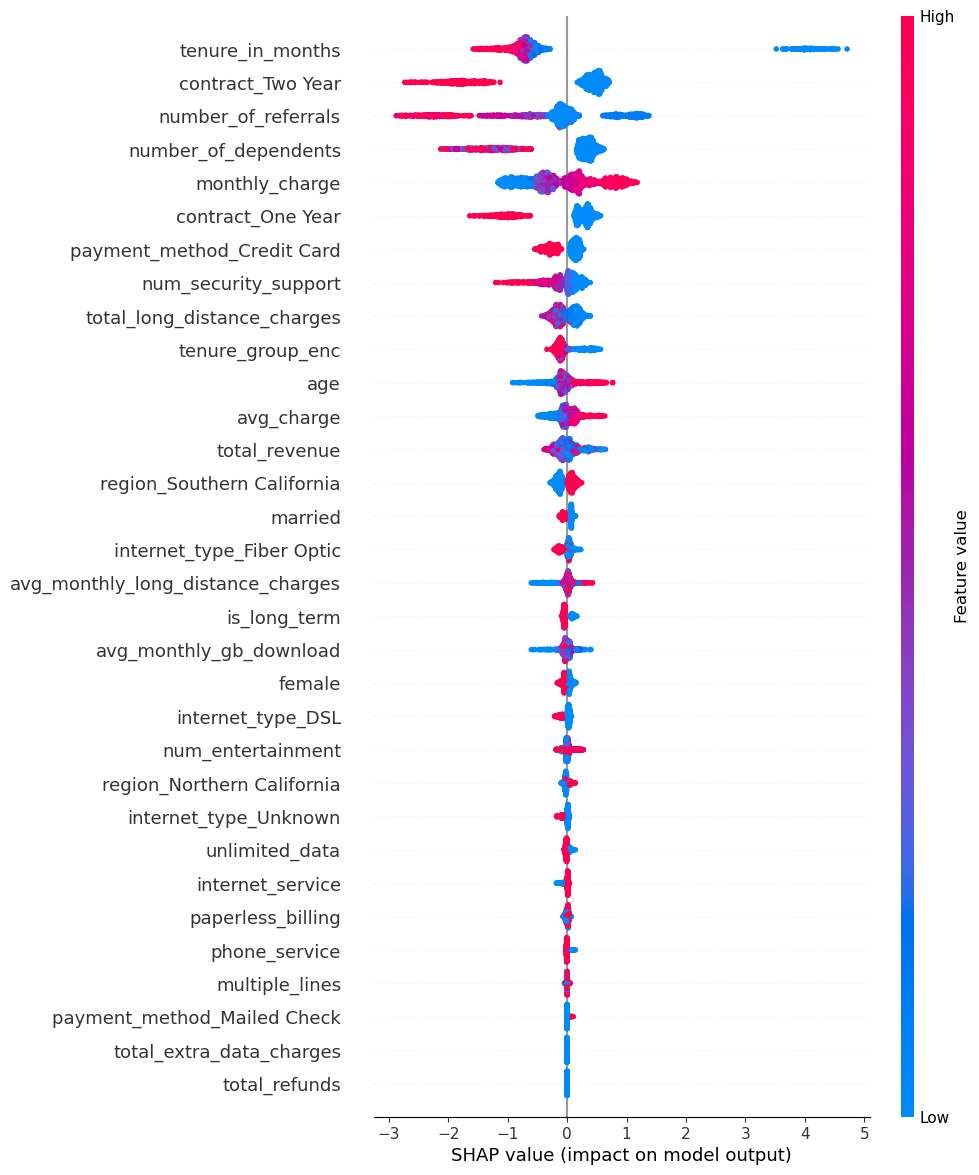

In [ ]:
shap.plots.beeswarm(xgb_shaps, max_display=36)

**=> Phân bố các tác động riêng lẻ của từng thuộc tính. Ví dụ: contract_Two Year - dãy chấm đỏ là giá trị cao (nhìn dải màu bên phải) và tác động của nó là âm (nhìn trục x bên dưới). Điều này nghĩa là giá trị contract_Two Year càng giảm, tác động để kết quả dự đoán là Churn càng lớn**

**Ngoài ra, độ phủ SHAP càng nhỏ và quanh trục 0 thì tác động hầu như càng nhỏ lên kết quả dự đoán**

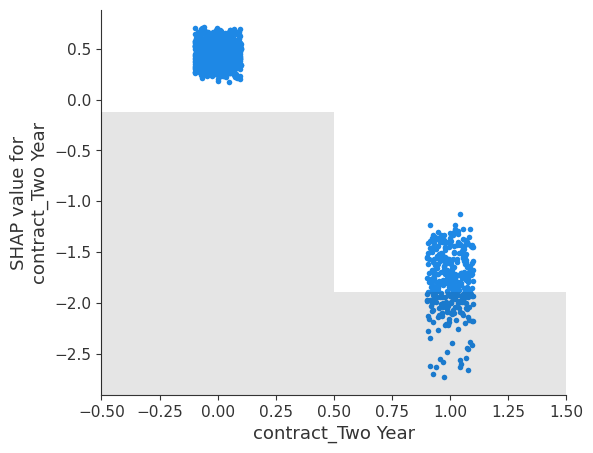

In [ ]:
shap.plots.scatter(xgb_shaps[:,"contract_Two Year"])

**=> contract_Two Year = 1 thì SHAP values dương (trục y) <=> tác động dương lên kết quả dự đoán là Churn. Ví dụ: P(y=churn) = 0.5. Nếu có contract_two Year = 0 thì P(y=churn) > 0.5**

In [ ]:
import math

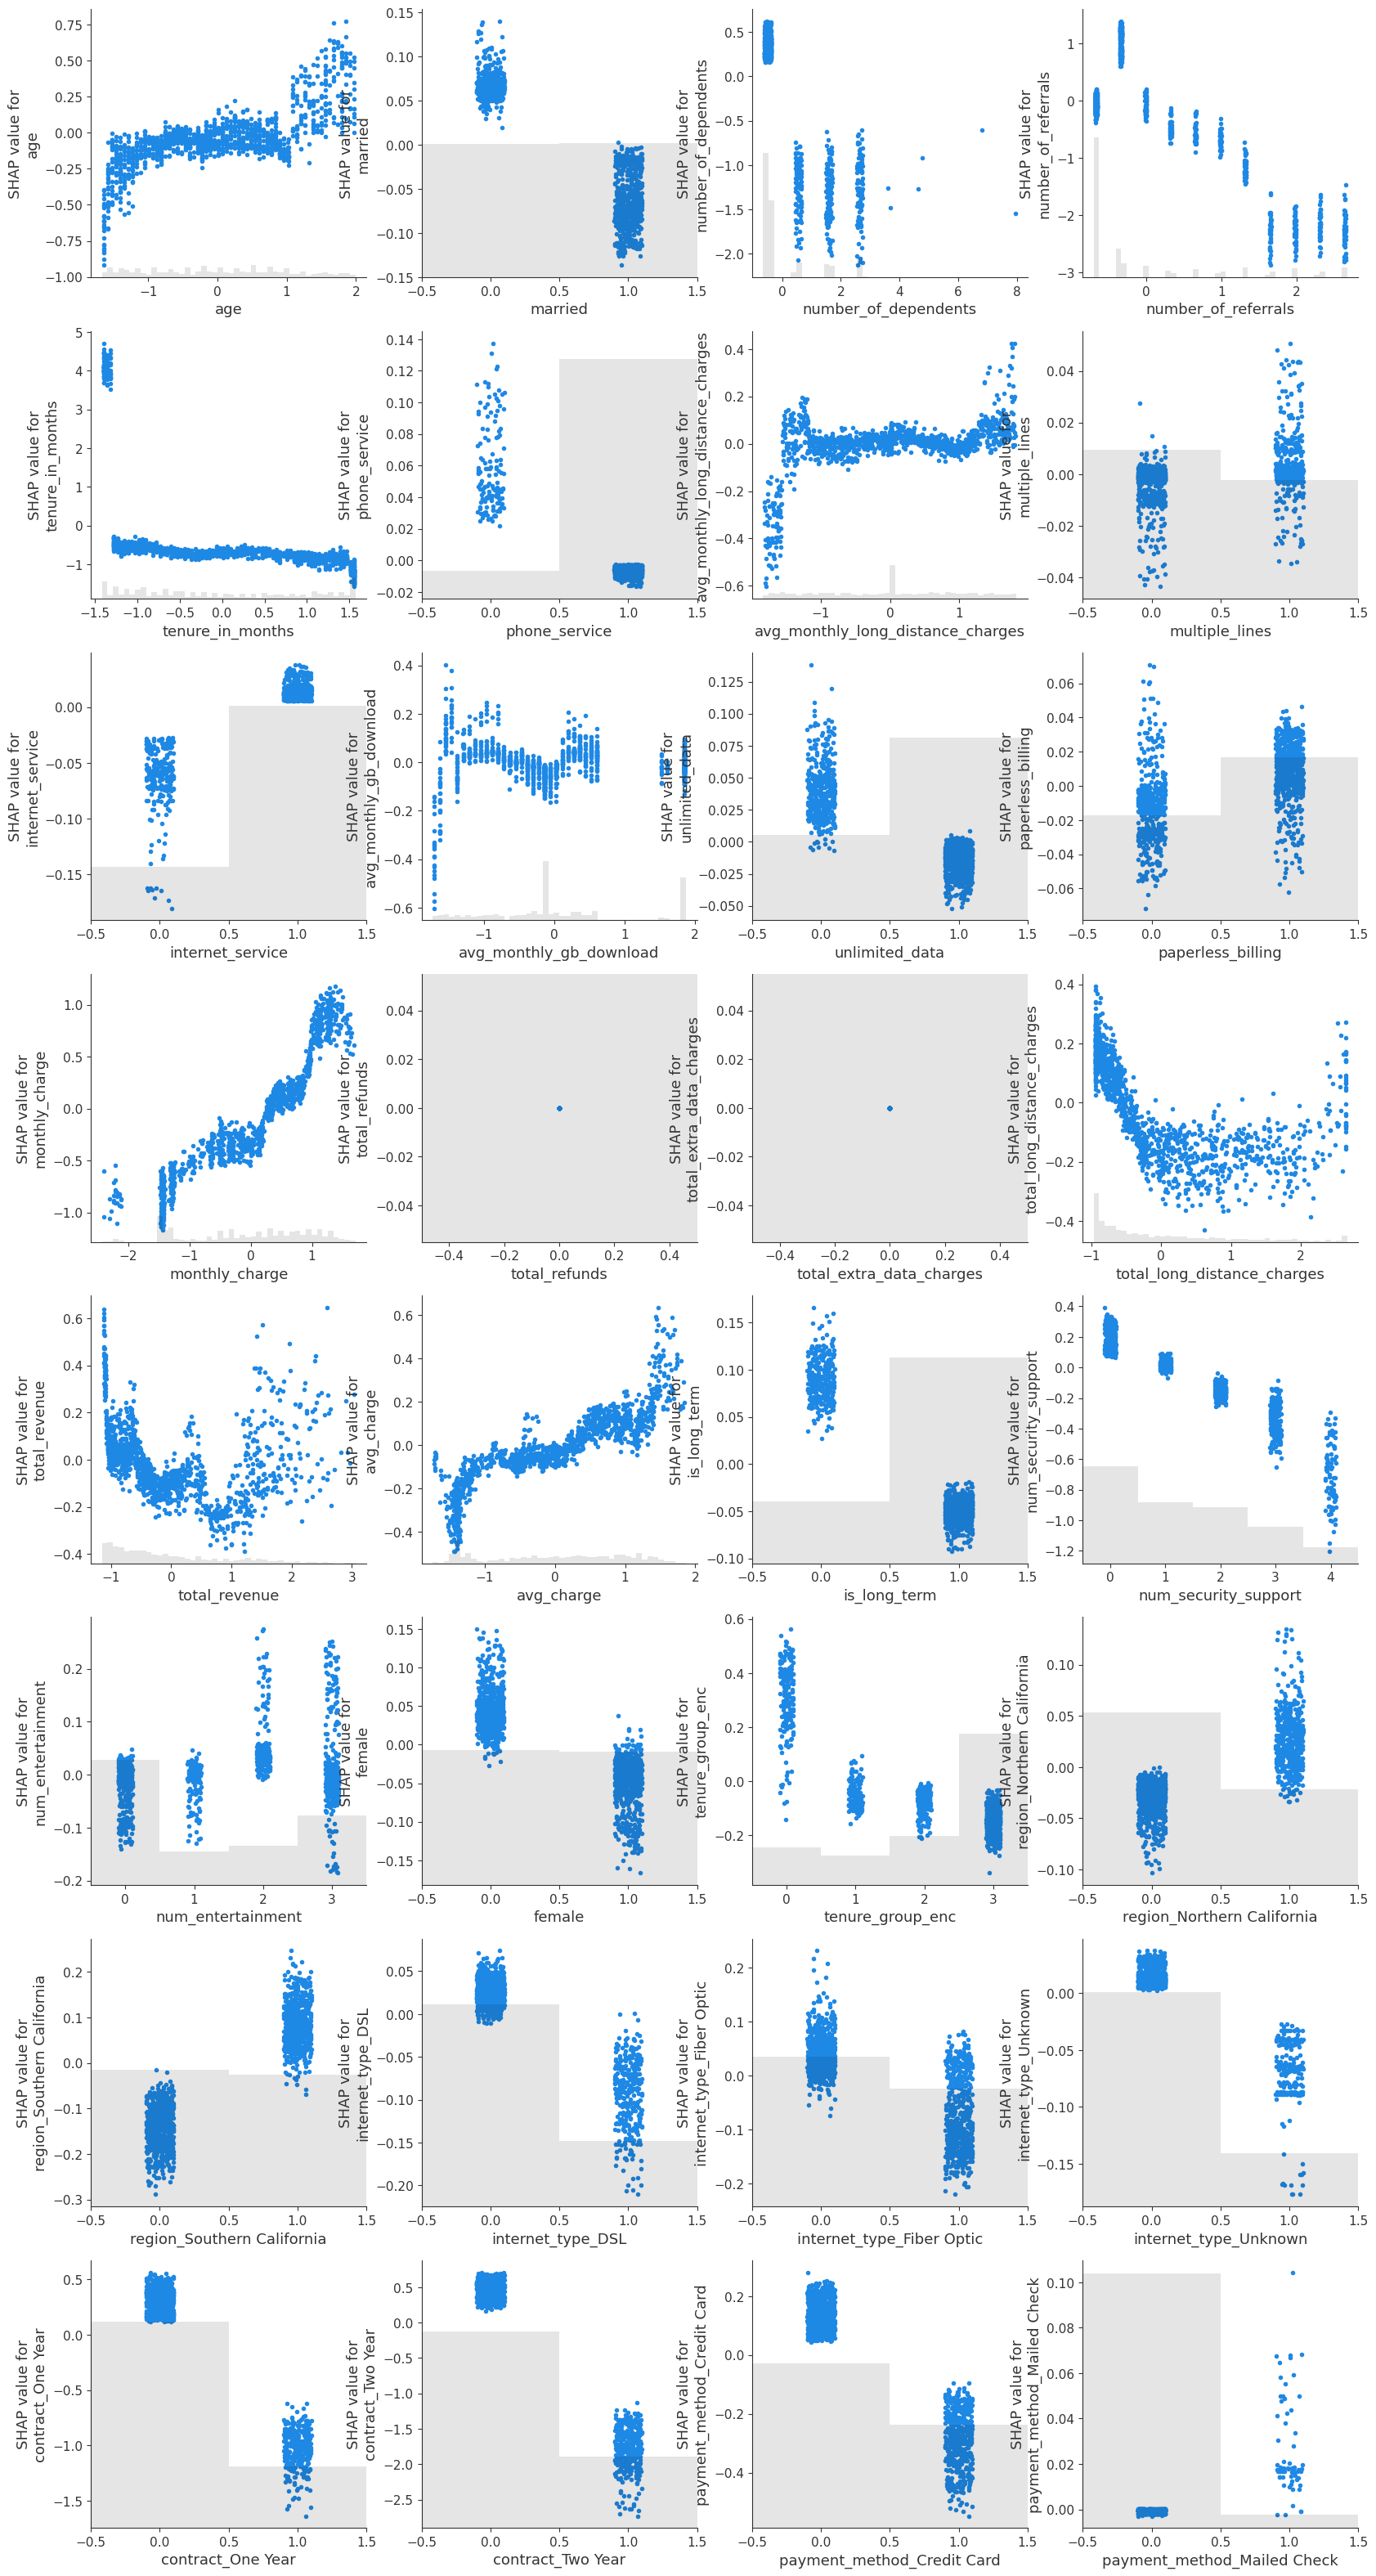

In [ ]:
num_features = len(X2.columns)
cols = 4
rows = math.ceil(num_features / cols)

# 2. Tạo Figure
plt.figure(figsize=(20, 5 * rows))

for i, column in enumerate(X2.columns):
    ax = plt.subplot(rows, cols, i + 1)
    
    shap.plots.scatter(
        xgb_shaps[:, column], 
        show=False, 
        ax=ax
    )

for i in range(num_features, rows * cols):
    plt.subplot(rows, cols, i + 1).axis('off')